```{contents}
```

## Demonstration

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.53MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 115kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 630kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.36MB/s]


Epoch [1/3] | D Loss: 0.0623 | G Loss: 6.0515
Epoch [2/3] | D Loss: 0.0010 | G Loss: 7.9422
Epoch [3/3] | D Loss: 0.0001 | G Loss: 10.2853


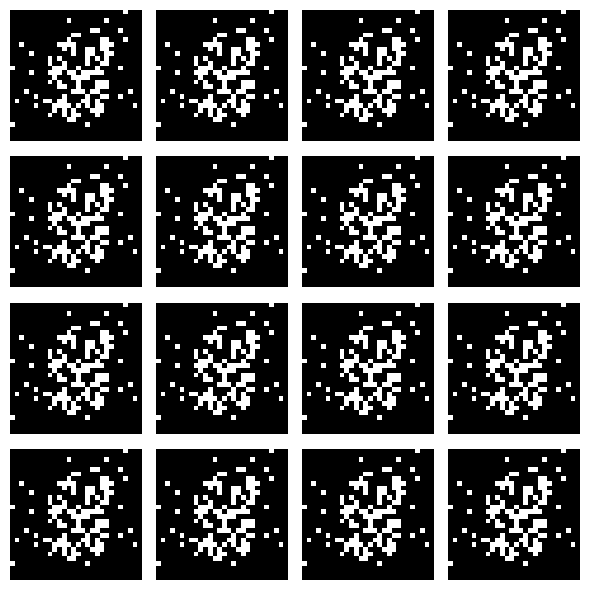

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. Data Preparation (MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
mnist = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
dataloader = DataLoader(mnist, batch_size=128, shuffle=True)

# 2. Define Generator
class Generator(nn.Module):
    def __init__(self, noise_dim=100, img_dim=28*28):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

# 3. Define Discriminator
class Discriminator(nn.Module):
    def __init__(self, img_dim=28*28):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# 4. Initialize networks and hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator().to(device)
discriminator = Discriminator().to(device)
criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)

# 5. Training Loop (Short Run for Demonstration)
epochs = 3
noise_dim = 100

for epoch in range(epochs):
    for batch_idx, (real, _) in enumerate(dataloader):
        real = real.view(-1, 28*28).to(device)
        batch_size = real.size(0)

        # Labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ----------------------
        # Train Discriminator
        # ----------------------
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_images = generator(noise)
        real_output = discriminator(real)
        fake_output = discriminator(fake_images.detach())

        d_loss_real = criterion(real_output, real_labels)
        d_loss_fake = criterion(fake_output, fake_labels)
        d_loss = d_loss_real + d_loss_fake

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # ----------------------
        # Train Generator
        # ----------------------
        fake_output = discriminator(fake_images)
        g_loss = criterion(fake_output, real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

# 6. Generate and visualize samples
generator.eval()
noise = torch.randn(16, noise_dim).to(device)
generated_images = generator(noise).view(-1, 1, 28, 28).detach().cpu()

plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(generated_images[i][0], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()


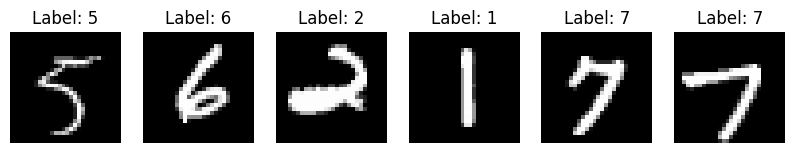

In [3]:
dataiter = iter(dataloader)
images, labels = next(dataiter)

# Step 3: Undo normalization for visualization
images = images * 0.5 + 0.5  # de-normalize from [-1,1] → [0,1]

# Step 4: Plot a grid of images
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')

plt.show()